# Convergência e Lei dos Grandes Números  

## Considere a estimativa da integral:

### I = ∫ [0, 1] ln( 1 + x) dx 

(a) Estime I usando Monte Carlo com amostragem uniforme.  
(b) Execute simulações com N = 10², 10³, 10⁴, 10⁵.  
(c) Plote o erro absoluto em função de N.  

<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%202/convergencia_e_lei_dos_grandes_numeros.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [ ]:
!pip install numpy
!pip install math
!pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math


Note: you may need to restart the kernel to use updated packages.


Valor exato I = 0.3862943611198906
N=   100   I_hat=0.36830341   |erro|=0.01799095
N=  1000   I_hat=0.37646295   |erro|=0.00983141
N= 10000   I_hat=0.38743632   |erro|=0.00114196
N=100000   I_hat=0.38674295   |erro|=0.00044859


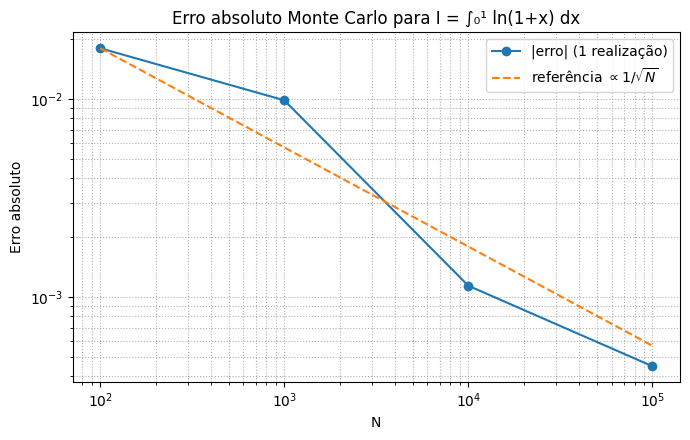

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ============================================================
# 0) Valor exato da integral (para medir o erro)
# I = ∫_0^1 ln(1+x) dx = 2 ln 2 - 1
# ============================================================
I_exato = 2*math.log(2) - 1

# ============================================================
# 1) Monte Carlo com amostragem uniforme
# Se U ~ Uniforme(0,1), então:
# I = E[ ln(1+U) ]
#
# Estimador:
# I_hat(N) = (1/N) * Σ ln(1 + U_i)
# ============================================================

# Semente para reprodutibilidade (para você obter resultados consistentes)
rng = np.random.default_rng(20260406)

# Tamanhos de amostra solicitados
Ns = np.array([10**2, 10**3, 10**4, 10**5])
Nmax = Ns.max()

# Geramos uma amostra grande de tamanho Nmax e reaproveitamos prefixos
U = rng.random(Nmax)         # U_i ~ Uniforme(0,1)
f = np.log(1 + U)            # f(U_i) = ln(1+U_i)

# Soma acumulada para calcular rapidamente as médias dos prefixos
soma_acumulada = np.cumsum(f)

# Estimativas para cada N:
# I_hat(N) = (soma dos primeiros N valores) / N
I_hat = soma_acumulada[Ns - 1] / Ns

# Erro absoluto
erro_abs = np.abs(I_hat - I_exato)

# ============================================================
# 2) Mostrar resultados numéricos
# ============================================================
print("Valor exato I =", I_exato)
for N, est, err in zip(Ns, I_hat, erro_abs):
    print(f"N={N:>6d}   I_hat={est:.8f}   |erro|={err:.8f}")

# ============================================================
# 3) Gráfico do erro absoluto em função de N
# (Escala log-log para visualizar taxa ~ 1/sqrt(N))
# ============================================================

# Linha de referência proporcional a 1/sqrt(N)
# (ajustada para passar aproximadamente pelo primeiro ponto)
c_ref = erro_abs[0] * math.sqrt(Ns[0])
ref = c_ref / np.sqrt(Ns)

plt.figure(figsize=(7, 4.5))
plt.loglog(Ns, erro_abs, marker='o', label='|erro| (1 realização)')
plt.loglog(Ns, ref, '--', label=r'referência $\propto 1/\sqrt{N}$')

plt.xlabel("N")
plt.ylabel("Erro absoluto")
plt.title("Erro absoluto Monte Carlo para I = ∫₀¹ ln(1+x) dx")
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()
